<a href="https://colab.research.google.com/github/sudarshinib2405-sys/24ADI204_DSV_Team1/blob/main/week3data_visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection – Data Cleaning

This Google Colab notebook performs data cleaning and basic visualization on `fraudTrain.csv`.

**Workflow:** Import → Before Cleaning → Cleaning → After Cleaning → Visualizations → Save Dataset

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Upload and Load Dataset

In [2]:
uploaded = files.upload()

df = pd.read_csv('fraudTrain.csv')

print('Dataset loaded successfully!')
print('Shape:', df.shape)

Saving fraudTrain.csv to fraudTrain.csv
Dataset loaded successfully!
Shape: (1296675, 23)


## 3. Before Cleaning – Initial Data Inspection

In [3]:
print('BEFORE CLEANING')
print('-' * 40)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

display(df.head())

BEFORE CLEANING
----------------------------------------
Rows: 1296675
Columns: 23
Missing values: 0
Duplicate rows: 0


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
print('Column names:')
for col in df.columns:
    print('-', col)

print('\nData types:')
display(df.dtypes)

Column names:
- Unnamed: 0
- trans_date_trans_time
- cc_num
- merchant
- category
- amt
- first
- last
- gender
- street
- city
- state
- zip
- lat
- long
- city_pop
- job
- dob
- trans_num
- unix_time
- merch_lat
- merch_long
- is_fraud

Data types:


,0
Unnamed: 0,int64
trans_date_trans_time,object
cc_num,int64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object


## 4. Cleaning

In [5]:
# Remove unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Remove duplicate rows
duplicates_removed = df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Handle missing numerical values with median
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Handle missing categorical values with mode
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Convert date/time columns
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

# Create useful time features
df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
df['transaction_day'] = df['trans_date_trans_time'].dt.day
df['transaction_month'] = df['trans_date_trans_time'].dt.month
df['transaction_weekday'] = df['trans_date_trans_time'].dt.dayofweek

# Create customer age feature
df['customer_age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).round(0)

# Remove original date columns after feature extraction
df.drop(['trans_date_trans_time', 'dob'], axis=1, inplace=True)

print('Cleaning completed successfully!')

Cleaning completed successfully!


## 5. After Cleaning – Data Quality Check

In [6]:
print('AFTER CLEANING')
print('-' * 40)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Duplicates removed:', duplicates_removed)

display(df.head())

AFTER CLEANING
----------------------------------------
Rows: 1296675
Columns: 25
Missing values: 0
Duplicate rows: 0
Duplicates removed: 0


,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,transaction_hour,transaction_day,transaction_month,transaction_weekday,customer_age
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,...,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,1,31.0
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,...,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,1,41.0
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,...,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,1,57.0
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,...,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1,1,52.0
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,...,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1,1,33.0


In [7]:
print('Missing values by column:')
display(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values by column:


,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0
city,0
state,0


## 6. Visualizations

### 6.1 Fraud vs Non-Fraud Transactions

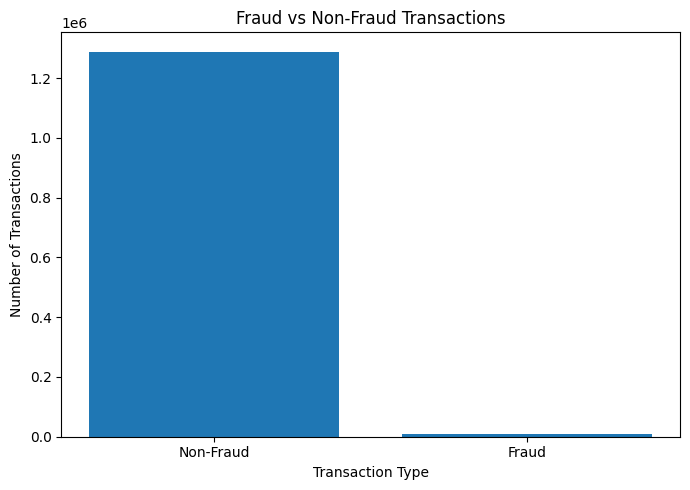

Non-Fraud: 1289169
Fraud: 7506


In [8]:
fraud_counts = df['is_fraud'].value_counts().sort_index()

labels = ['Non-Fraud', 'Fraud']

plt.figure(figsize=(7, 5))
plt.bar(labels, fraud_counts.values)
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

print('Non-Fraud:', fraud_counts.get(0, 0))
print('Fraud:', fraud_counts.get(1, 0))

### 6.2 Transaction Amount Distribution

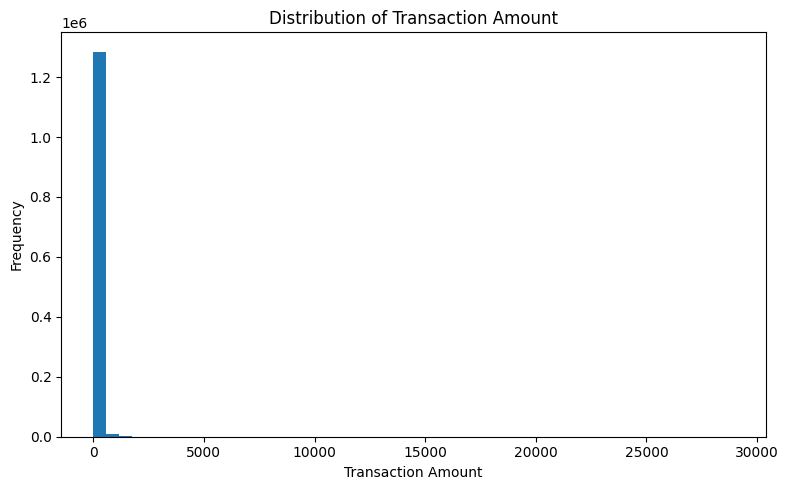

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['amt'], bins=50)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 6.3 Transactions by Hour

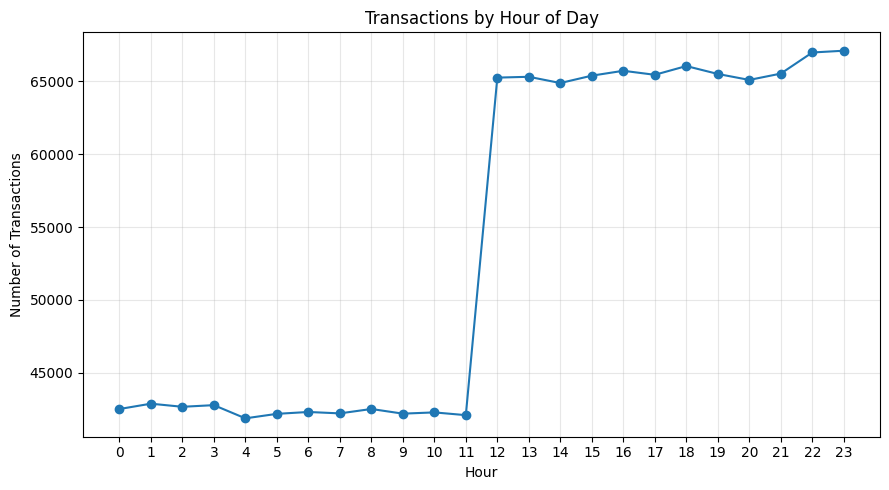

In [10]:
hour_counts = df['transaction_hour'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(hour_counts.index, hour_counts.values, marker='o')
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Fraud Rate by Transaction Hour

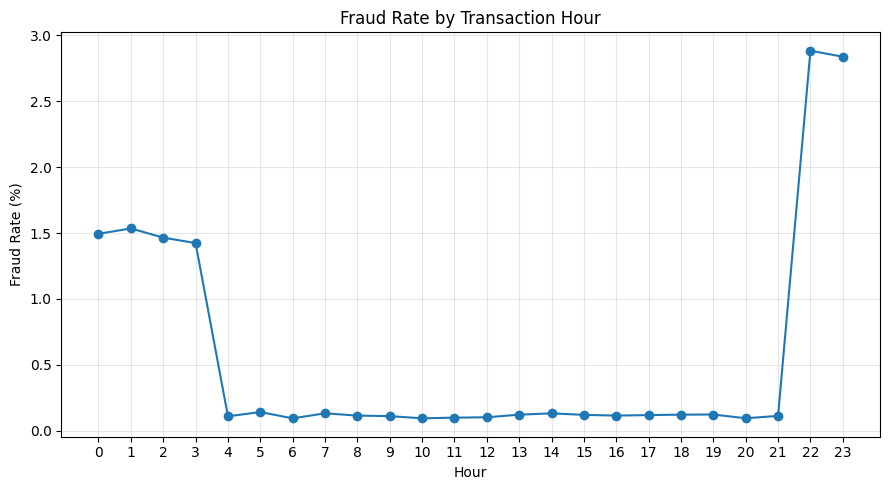

In [11]:
fraud_rate_by_hour = df.groupby('transaction_hour')['is_fraud'].mean() * 100

plt.figure(figsize=(9, 5))
plt.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, marker='o')
plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save Cleaned Dataset

In [12]:
output_file = 'fraudTrain_cleaned.csv'
df.to_csv(output_file, index=False)

print(f'Cleaned dataset saved as {output_file}')
files.download(output_file)

Cleaned dataset saved as fraudTrain_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Cleaning Summary

The dataset was checked for missing values and duplicate records, unnecessary index information was removed, date fields were converted, and useful time-based and age-based features were created. The cleaned dataset was then visualized and saved as `fraudTrain_cleaned.csv`.

**Note:** Class imbalance was not corrected during basic data cleaning. It can be handled later during machine-learning preprocessing.